<a href="https://colab.research.google.com/github/jabladez/quant-trading-101/blob/main/Quant_trading_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
("i started")

'i started'

In [4]:
import yfinance as yf
data = yf.download("SPY", start="2024-01-01")
data.head()

/tmp/ipykernel_719/247530543.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2024-01-02,457.672729,458.660427,455.581172,457.198266,123623700
2024-01-03,453.935059,456.259002,453.334710,455.523075,103585900
2024-01-04,452.472870,456.036251,452.250147,453.460538,84232200
2024-01-05,453.092621,455.532757,451.649816,452.676224,86118900
2024-01-08,459.560974,459.706215,453.460590,453.586475,74879100


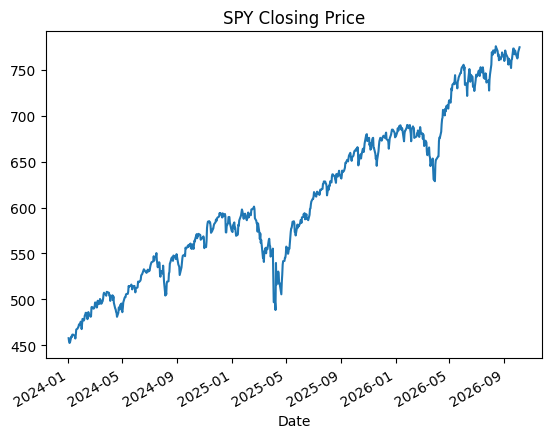

In [7]:
import matplotlib.pyplot as plt
# Plot the closing price
data['Close']['SPY'].plot(title="SPY Closing Price")
# Show the plot
plt.show()

<Axes: title={'center': 'SPY Closing Price vs 50-Day Moving Average'}, xlabel='Date'>

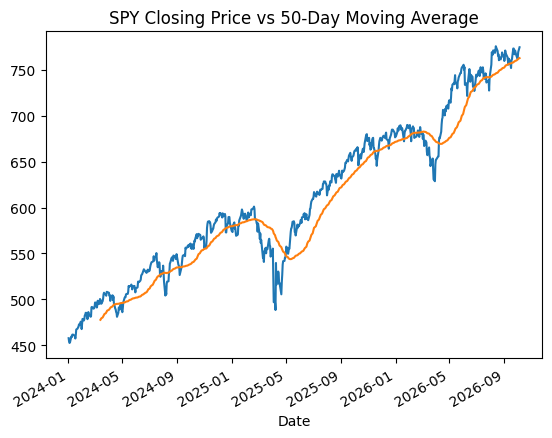

In [9]:
import matplotlib.pyplot as plt
# Plot the closing Price
data['Close']['SPY'].plot(title="SPY Closing Price vs 50-Day Moving Average")

#Calculate and Plot the 50-day moving average
data['Close']['SPY'].rolling(window=50).mean().plot(label="50-Day MA")

# Add a legend so we know which line is which plt.legend()

# Show the plot plt.show()

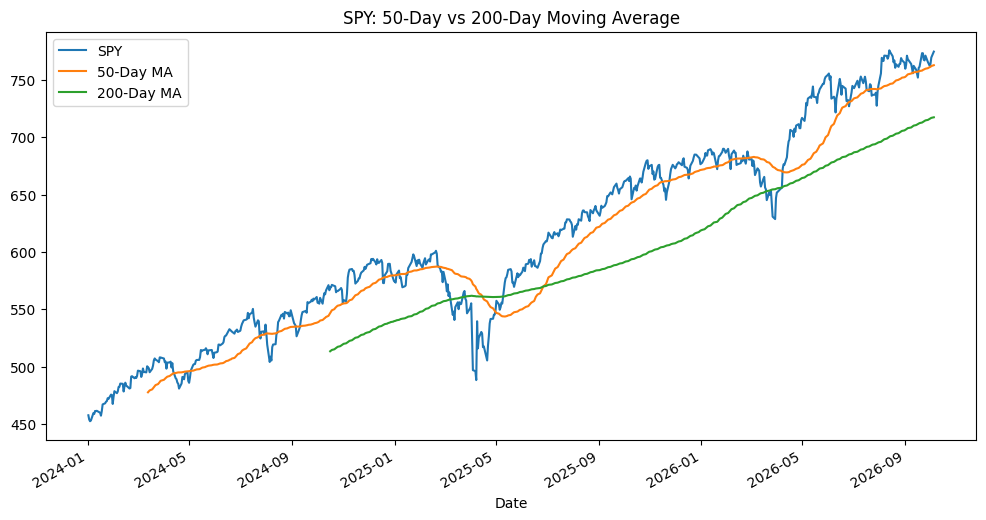

In [11]:
import matplotlib.pyplot as plt

# Plot the closing price
data ['Close']['SPY'].plot(title="SPY: 50-Day vs 200-Day Moving Average", figsize=(12,6))

# Calculate and plot the 50-Day moving average
data['Close']['SPY'].rolling(window=50).mean().plot(label="50-Day MA")

# Calculate and plot the 200-day moving average
data['Close']['SPY'].rolling(window=200).mean().plot(label="200-Day MA")

# Add a legend
plt.legend()

# Show the plot
plt.show()

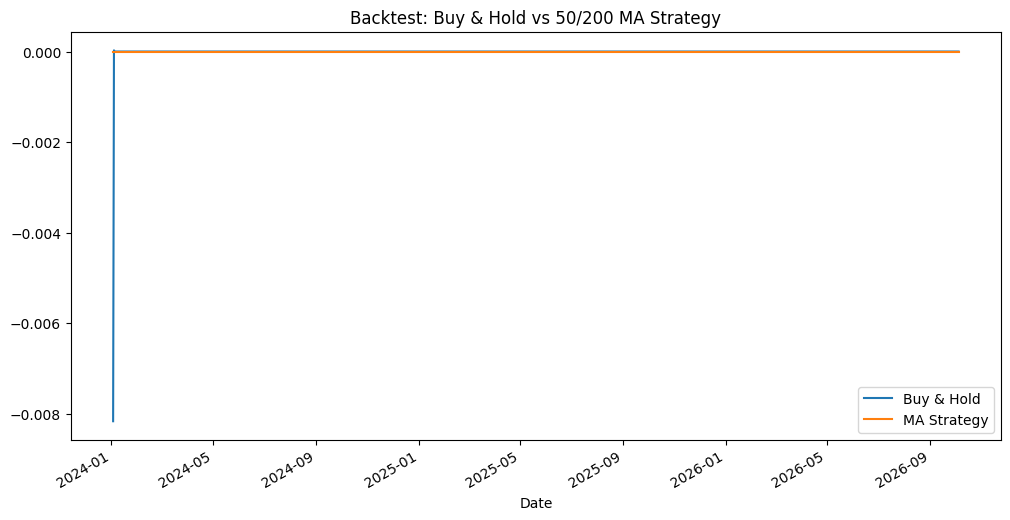

In [12]:
import matplotlib.pyplot as plt

# 1. Calculate the moving averages
data['MA50'] = data['Close']['SPY'].rolling(window=50).mean()
data['MA200'] = data['Close']['SPY'].rolling(window=200).mean()

# 2. Create the signal: 1 = Buy & Hold, 0 = Cash
data['Signal'] = 0.0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1.0

# 3. Calculate daily returns
data['Market_Returns'] = data['Close']['SPY'].pct_change()

# 4. Calculate strategy returns (shifted by 1 day so we don't cheat and look into the future)
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

# 5. Plot the cumulative growth of $1
data[['Market_Returns', 'Strategy_Returns']].cumprod().plot(title="Backtest: Buy & Hold vs 50/200 MA Strategy", figsize=(12,6))
plt.legend(["Buy & Hold", "MA Strategy"])
plt.show()


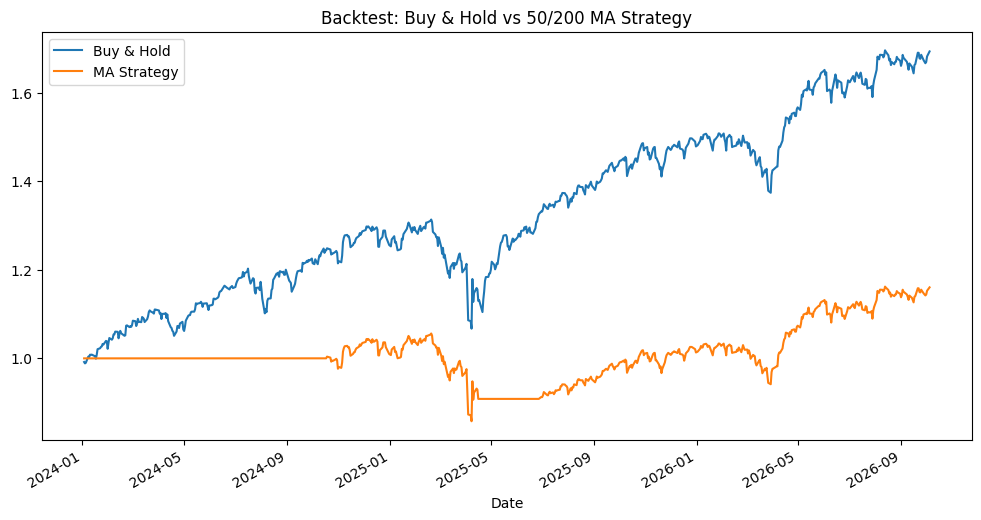

In [13]:
import matplotlib.pyplot as plt

# 1. Calculate the moving averages
data['MA50'] = data['Close']['SPY'].rolling(window=50).mean()
data['MA200'] = data['Close']['SPY'].rolling(window=200).mean()

# 2. Create the signal: 1 = Buy & Hold, 0 = Cash
data['Signal'] = 0.0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1.0

# 3. Calculate daily returns
data['Market_Returns'] = data['Close']['SPY'].pct_change()

# 4. Calculate strategy returns (shifted by 1 day so we don't cheat)
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

# 5. Plot the cumulative growth of $1 (Adding 1 to fix the compounding bug!)
(1 + data[['Market_Returns', 'Strategy_Returns']]).cumprod().plot(title="Backtest: Buy & Hold vs 50/200 MA Strategy", figsize=(12,6))

plt.legend(["Buy & Hold", "MA Strategy"])
plt.show()

In [2]:
import numpy as np
import pandas as pd

# Drop the NaN values created by the 200-day moving average
clean_Data = data.dropna()

# Define a function to calculate metrics
def get_metrics(returns, name):
    # 1. Total Return
    total_return = (1 + returns).prod() - 1

    # 2. CAGR (Compound Annual Growth Rate) - assuming 252 trading days a year
    cagr = (1 + total_return) ** (252 / len(returns)) - 1

    # 3. Volatility (Annualized Standard Deviation)
    vol = returns.std() * np.sqrt(252)

    # 4. Sharpe Ratio (Return per unit of risk, assuming 0% risk-free rate for simplicity)
    sharpe = cagr / vol if vol != 0 else 0

    # 5. Max Drawdown (The biggest peak-to-trough drop)
    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()

    # Print the results
    print(f"--- {name} ---")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return (CAGR): {cagr:.2%}")
    print(f"Annualized Volatility: {vol:.2%}")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print("-" * 25)

# Run the metrics for both strategies
get_metrics(clean_data['Market_Returns'], "Buy & Hold")
get_metrics(clean_data['Strategy_Returns'], "50/200 MA Strategy")

NameError: name 'data' is not defined

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Download the data
data = yf.download("SPY", start="2024-01-01", progress=False)

# 2. Calculate the moving averages
data['MA50'] = data['Close']['SPY'].rolling(window=50).mean()
data['MA200'] = data['Close']['SPY'].rolling(window=200).mean()

# 3. Create the signal and calculate returns
data['Market_Returns'] = data['Close']['SPY'].pct_change()
data['Signal'] = 0.0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1.0
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

# 4. Drop the NaN values created by the 200-day moving average
clean_data = data.dropna()

# 5. Define a function to calculate metrics
def get_metrics(returns, name):
    total_return = (1 + returns).prod() - 1
    cagr = (1 + total_return) ** (252 / len(returns)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0

    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()

    print(f"--- {name} ---")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return (CAGR): {cagr:.2%}")
    print(f"Annualized Volatility: {vol:.2%}")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print("-" * 25)

# 6. Run the metrics for both strategies
get_metrics(clean_data['Market_Returns'], "Buy & Hold")
get_metrics(clean_data['Strategy_Returns'], "50/200 MA Strategy")

/tmp/ipykernel_6937/2096376811.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SPY", start="2024-01-01", progress=False)


--- Buy & Hold ---
Total Return: 37.15%
Annualized Return (CAGR): 17.45%
Annualized Volatility: 16.58%
Sharpe Ratio: 1.05
Max Drawdown: -18.76%
-------------------------
--- 50/200 MA Strategy ---
Total Return: 16.39%
Annualized Return (CAGR): 8.03%
Annualized Volatility: 15.76%
Sharpe Ratio: 0.51
Max Drawdown: -18.76%
-------------------------


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Download a longer timeframe and a more volatile asset
data = yf.download("NVDA", start="2015-01-01", progress=False)

# 2. Calculate the moving averages
data['MA50'] = data['Close']['NVDA'].rolling(window=50).mean()
data['MA200'] = data['Close']['NVDA'].rolling(window=200).mean()

# 3. Create the signal and calculate returns
data['Market_Returns'] = data['Close']['NVDA'].pct_change()
data['Signal'] = 0.0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1.0
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

# 4. Drop the NaN values created by the 200-day moving average
clean_data = data.dropna()

# 5. Define a function to calculate metrics
def get_metrics(returns, name):
    total_return = (1 + returns).prod() - 1
    cagr = (1 + total_return) ** (252 / len(returns)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0

    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()

    print(f"--- {name} ---")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return (CAGR): {cagr:.2%}")
    print(f"Annualized Volatility: {vol:.2%}")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print("-" * 25)

# 6. Run the metrics
get_metrics(clean_data['Market_Returns'], "Buy & Hold NVDA")
get_metrics(clean_data['Strategy_Returns'], "50/200 MA Strategy NVDA")

/tmp/ipykernel_6937/1421505952.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NVDA", start="2015-01-01", progress=False)


--- Buy & Hold NVDA ---
Total Return: 35609.71%
Annualized Return (CAGR): 71.07%
Annualized Volatility: 48.94%
Sharpe Ratio: 1.45
Max Drawdown: -66.34%
-------------------------
--- 50/200 MA Strategy NVDA ---
Total Return: 34001.39%
Annualized Return (CAGR): 70.35%
Annualized Volatility: 43.01%
Sharpe Ratio: 1.64
Max Drawdown: -37.55%
-------------------------


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download the data
data = yf.download("NVDA", start="2015-01-01", progress=False)
data['Market_Returns'] = data['Close']['NVDA'].pct_change()

# Function to run a backtest with custom MA windows
def test_strategy(short_window, long_window, name):
    # Calculate MAs
    data['MA_short'] = data['Close']['NVDA'].rolling(window=short_window).mean()
    data['MA_long'] = data['Close']['NVDA'].rolling(window=long_window).mean()

    # Signal
    data['Signal'] = 0.0
    data.loc[data['MA_short'] > data['MA_long'], 'Signal'] = 1.0
    data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

    # Clean data
    clean = data.dropna()

    # Metrics
    total_ret = (1 + clean['Strategy_Returns']).prod() - 1
    cagr = (1 + total_ret) ** (252 / len(clean)) - 1
    vol = clean['Strategy_Returns'].std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0

    cum_ret = (1 + clean['Strategy_Returns']).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()

    print(f"--- {name} ({short_window}/{long_window}) ---")
    print(f"CAGR: {cagr:.2%} | Sharpe: {sharpe:.2f} | Max DD: {max_dd:.2%}")
    print("-" * 40)

# Run the tests
test_strategy(20, 100, "Fast MA")
test_strategy(50, 200, "Classic MA")
test_strategy(100, 300, "Slow MA")

# Print Buy & Hold for comparison
bh_cagr = ((1 + data['Market_Returns'].dropna()).prod()) ** (252 / len(data.dropna())) - 1
bh_cum = (1 + data['Market_Returns'].dropna()).cumprod()
bh_dd = ((bh_cum - bh_cum.cummax()) / bh_cum.cummax()).min()
print(f"--- Buy & Hold ---")
print(f"CAGR: {bh_cagr:.2%} | Max DD: {bh_dd:.2%}")

/tmp/ipykernel_6937/451657809.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NVDA", start="2015-01-01", progress=False)


--- Fast MA (20/100) ---
CAGR: 51.76% | Sharpe: 1.29 | Max DD: -49.00%
----------------------------------------
--- Classic MA (50/200) ---
CAGR: 70.35% | Sharpe: 1.64 | Max DD: -37.55%
----------------------------------------
--- Slow MA (100/300) ---
CAGR: 56.91% | Sharpe: 1.27 | Max DD: -55.61%
----------------------------------------
--- Buy & Hold ---
CAGR: 79.97% | Max DD: -66.34%


In [6]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download data
data = yf.download("NVDA", start="2015-01-01", progress=False)
data['Market_Returns'] = data['Close']['NVDA'].pct_change()
data['MA50'] = data['Close']['NVDA'].rolling(window=50).mean()
data['MA200'] = data['Close']['NVDA'].rolling(window=200).mean()

# Signal and Returns
data['Signal'] = 0.0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1.0
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

# Calculate number of trades
data['Trades'] = data['Signal'].diff().abs()
total_trades = data['Trades'].sum()

# Apply a 0.1% cost per trade
cost_per_trade = 0.001
data['Strategy_Returns_With_Fees'] = data['Strategy_Returns'] - (data['Trades'].shift(1) * cost_per_trade)

# Metrics function
def get_metrics(returns, name):
    clean = returns.dropna()
    total_ret = (1 + clean).prod() - 1
    cagr = (1 + total_ret) ** (252 / len(clean)) - 1
    vol = clean.std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0
    cum_ret = (1 + clean).cumprod()
    peak = cum_ret.cummax()
    max_dd = ((cum_ret - peak) / peak).min()
    print(f"--- {name} ---")
    print(f"CAGR: {cagr:.2%} | Sharpe: {sharpe:.2f} | Max DD: {max_dd:.2%}")

# Compare No-Fee vs With Fees
print(f"Total Trades: {int(total_trades)}")
get_metrics(data['Strategy_Returns'], "MA Strategy (No Fees)")
get_metrics(data['Strategy_Returns_With_Fees'], "MA Strategy (With 0.1% Fees)")

/tmp/ipykernel_6937/3459479750.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NVDA", start="2015-01-01", progress=False)


Total Trades: 7
--- MA Strategy (No Fees) ---
CAGR: 64.38% | Sharpe: 1.55 | Max DD: -37.55%
--- MA Strategy (With 0.1% Fees) ---
CAGR: 64.31% | Sharpe: 1.55 | Max DD: -37.55%


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download data
data = yf.download("NVDA", start="2015-01-01", progress=False)
data['Market_Returns'] = data['Close']['NVDA'].pct_change()
data['MA50'] = data['Close']['NVDA'].rolling(window=50).mean()
data['MA200'] = data['Close']['NVDA'].rolling(window=200).mean()

# Signal: 1 = Long, -1 = Short, 0 = Cash
data['Signal'] = 0.0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1.0
data.loc[data['MA50'] < data['MA200'], 'Signal'] = -1.0 # The Short Signal

# Strategy Returns
data['Strategy_Returns'] = data['Signal'].shift(1) * data['Market_Returns']

# Clean
clean = data.dropna()

# Metrics function
def get_metrics(returns, name):
    total_ret = (1 + returns).prod() - 1
    cagr = (1 + total_ret) ** (252 / len(returns)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0
    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    max_dd = ((cum_ret - peak) / peak).min()
    print(f"--- {name} ---")
    print(f"CAGR: {cagr:.2%} | Sharpe: {sharpe:.2f} | Max DD: {max_dd:.2%}")

# Compare
get_metrics(clean['Market_Returns'], "Buy & Hold NVDA")
get_metrics(clean['Strategy_Returns'], "Long/Short 50/200 MA")

/tmp/ipykernel_6937/1441188149.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NVDA", start="2015-01-01", progress=False)


--- Buy & Hold NVDA ---
CAGR: 71.07% | Sharpe: 1.45 | Max DD: -66.34%
--- Long/Short 50/200 MA ---
CAGR: 60.79% | Sharpe: 1.24 | Max DD: -47.66%


/tmp/ipykernel_6937/3668943637.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", progress=False)['Close']


--- SPY Buy & Hold ---
CAGR: 13.87% | Sharpe: 0.79 | Max DD: -33.72%
--- Diversified 4-Asset Portfolio (MA Strategy) ---
CAGR: 8.75% | Sharpe: 0.96 | Max DD: -15.45%


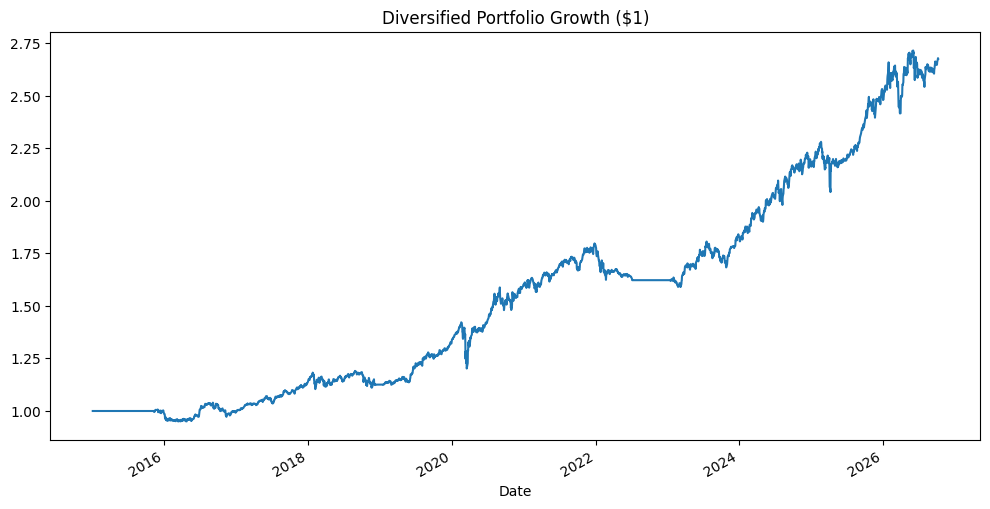

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define our universe
tickers = ['SPY', 'QQQ', 'TLT', 'GLD']

# 2. Download data for all of them
data = yf.download(tickers, start="2015-01-01", progress=False)['Close']

# 3. Store strategy returns for each asset
strategy_returns = pd.DataFrame()

for ticker in tickers:
    # Calculate MAs
    data[f'{ticker}_MA50'] = data[ticker].rolling(window=50).mean()
    data[f'{ticker}_MA200'] = data[ticker].rolling(window=200).mean()

    # Signal
    data[f'{ticker}_Signal'] = 0.0
    data.loc[data[f'{ticker}_MA50'] > data[f'{ticker}_MA200'], f'{ticker}_Signal'] = 1.0

    # Returns
    data[f'{ticker}_Returns'] = data[ticker].pct_change()
    data[f'{ticker}_Strat_Returns'] = data[f'{ticker}_Signal'].shift(1) * data[f'{ticker}_Returns']

    # Add to our portfolio dataframe
    strategy_returns[ticker] = data[f'{ticker}_Strat_Returns']

# 4. Create the Portfolio (Equal Weight: 25% each)
portfolio_returns = strategy_returns.mean(axis=1)

# 5. Metrics function
def get_metrics(returns, name):
    clean = returns.dropna()
    total_ret = (1 + clean).prod() - 1
    cagr = (1 + total_ret) ** (252 / len(clean)) - 1
    vol = clean.std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0
    cum_ret = (1 + clean).cumprod()
    peak = cum_ret.cummax()
    max_dd = ((cum_ret - peak) / peak).min()
    print(f"--- {name} ---")
    print(f"CAGR: {cagr:.2%} | Sharpe: {sharpe:.2f} | Max DD: {max_dd:.2%}")

# 6. Compare Portfolio vs Just SPY
get_metrics(data['SPY_Returns'], "SPY Buy & Hold")
get_metrics(portfolio_returns, "Diversified 4-Asset Portfolio (MA Strategy)")

# 7. Plot the equity curve
(1 + portfolio_returns.dropna()).cumprod().plot(title="Diversified Portfolio Growth ($1)", figsize=(12,6))
plt.show()

In [9]:
import pandas as pd
import numpy as np

# 1. Calculate rolling volatility for each asset's strategy
strategy_vol = strategy_returns.rolling(window=60).std() * np.sqrt(252)

# 2. Inverse Volatility Weights (Risk Parity)
# The less volatile the asset, the higher the weight
inverse_vol = 1 / strategy_vol
weights = inverse_vol.div(inverse_vol.sum(axis=1), axis=0)

# 3. Create the Risk Parity Portfolio Returns
portfolio_returns_rp = (strategy_returns * weights).sum(axis=1)

# 4. Metrics function
def get_metrics(returns, name):
    clean = returns.dropna()
    total_ret = (1 + clean).prod() - 1
    cagr = (1 + total_ret) ** (252 / len(clean)) - 1
    vol = clean.std() * np.sqrt(252)
    sharpe = cagr / vol if vol != 0 else 0
    cum_ret = (1 + clean).cumprod()
    peak = cum_ret.cummax()
    max_dd = ((cum_ret - peak) / peak).min()
    print(f"--- {name} ---")
    print(f"CAGR: {cagr:.2%} | Sharpe: {sharpe:.2f} | Max DD: {max_dd:.2%}")

# 5. Compare Equal Weight vs Risk Parity
get_metrics(portfolio_returns, "Equal Weight Portfolio")
get_metrics(portfolio_returns_rp, "Risk Parity Portfolio")

--- Equal Weight Portfolio ---
CAGR: 8.75% | Sharpe: 0.96 | Max DD: -15.45%
--- Risk Parity Portfolio ---
CAGR: 6.27% | Sharpe: 0.92 | Max DD: -12.95%
